# Autoencoders for Dimensionality Reduction on MNIST

This notebook demonstrates the implementation and analysis of autoencoders for dimensionality reduction using the MNIST dataset. We'll explore:

1. **Data Preparation**: Downloading and organizing MNIST data
2. **Autoencoder Architecture**: Building encoder and decoder networks
3. **Training**: Optimizing the reconstruction loss
4. **Analysis**: Evaluating compression quality and generative limitations
5. **Comparison**: Understanding why autoencoders lack generative capacity

## Key Learning Objectives
- Understand how autoencoders work for dimensionality reduction
- See that autoencoders are good at compression but lack generative capacity
- Compare with other dimensionality reduction techniques
- Visualize the learned latent representations

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create data directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
    print("Created data directory")
else:
    print("Data directory already exists")

Using device: cpu
Created data directory


## 2. Data Loading and Preparation

In [2]:
# Download and load MNIST dataset
print("Downloading MNIST dataset...")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load training data
train_dataset = datasets.MNIST('data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('data', train=False, download=True, transform=transform)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Number of classes: {len(train_dataset.classes)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.22MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.90MB/s]

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10


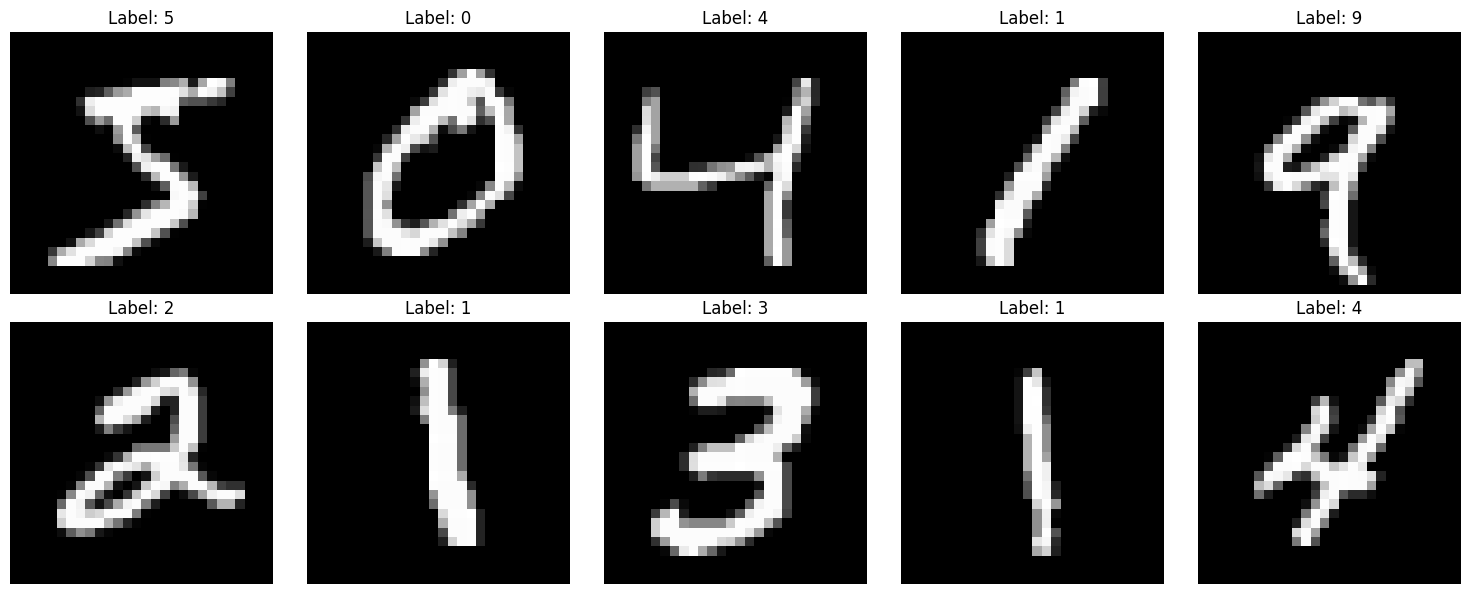

Original image shape: torch.Size([1, 28, 28])
Original image size: 784 parameters


In [3]:
# Visualize some sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    row, col = i // 5, i % 5
    img, label = train_dataset[i]
    axes[row, col].imshow(img.squeeze(), cmap='gray')
    axes[row, col].set_title(f'Label: {label}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

# Show original image dimensions
sample_img, _ = train_dataset[0]
print(f"Original image shape: {sample_img.shape}")
print(f"Original image size: {sample_img.numel()} parameters")

## 3. Autoencoder Architecture

We'll implement a simple autoencoder with:
- **Encoder**: Converts 784-dimensional input (28x28) to a lower-dimensional latent space
- **Decoder**: Reconstructs the original image from the latent representation
- **Latent Space**: Much smaller than the input (e.g., 32 dimensions for 96% compression)

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32, hidden_dims=[512, 256, 128]):
        super(Autoencoder, self).__init__()
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim
        
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Decoder
        decoder_layers = []
        hidden_dims_reversed = hidden_dims[::-1]
        prev_dim = latent_dim
        
        for hidden_dim in hidden_dims_reversed:
            decoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim
        
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        decoder_layers.append(nn.Sigmoid())  # Output values between 0 and 1
        self.decoder = nn.Sequential(*decoder_layers)
        
    def forward(self, x):
        # Flatten input
        x = x.view(x.size(0), -1)
        
        # Encode
        latent = self.encoder(x)
        
        # Decode
        reconstructed = self.decoder(latent)
        
        return reconstructed, latent
    
    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)
    
    def decode(self, latent):
        return self.decoder(latent)

# Initialize model
latent_dim = 32
autoencoder = Autoencoder(input_dim=784, latent_dim=latent_dim).to(device)

# Calculate compression ratio
compression_ratio = (784 - latent_dim) / 784 * 100
print(f"Autoencoder Architecture:")
print(f"Input dimension: 784 (28x28)")
print(f"Latent dimension: {latent_dim}")
print(f"Compression ratio: {compression_ratio:.1f}%")
print(f"Model parameters: {sum(p.numel() for p in autoencoder.parameters()):,}")

# Test forward pass
sample_batch = torch.randn(4, 1, 28, 28).to(device)
reconstructed, latent = autoencoder(sample_batch)
print(f"\nTest forward pass:")
print(f"Input shape: {sample_batch.shape}")
print(f"Latent shape: {latent.shape}")
print(f"Output shape: {reconstructed.shape}")

Autoencoder Architecture:
Input dimension: 784 (28x28)
Latent dimension: 32
Compression ratio: 95.9%
Model parameters: 1,144,880

Test forward pass:
Input shape: torch.Size([4, 1, 28, 28])
Latent shape: torch.Size([4, 32])
Output shape: torch.Size([4, 784])


## 4. Training the Autoencoder

In [5]:
# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Training function
def train_epoch(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0
    
    for batch_idx, (data, _) in enumerate(tqdm(dataloader, desc="Training")):
        data = data.to(device)
        
        optimizer.zero_grad()
        reconstructed, _ = model(data)
        loss = criterion(reconstructed, data.view(data.size(0), -1))
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Validation function
def validate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc="Validation"):
            data = data.to(device)
            reconstructed, _ = model(data)
            loss = criterion(reconstructed, data.view(data.size(0), -1))
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Training loop
num_epochs = 50
train_losses = []
val_losses = []

print(f"Starting training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    train_loss = train_epoch(autoencoder, train_loader, criterion, optimizer)
    val_loss = validate(autoencoder, test_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("Training completed!")

Starting training for 50 epochs...


Validation: 100%|██████████| 79/79 [00:01<00:00, 46.90it/s]


Epoch [10/50] - Train Loss: 0.488634, Val Loss: 0.493197


Validation: 100%|██████████| 79/79 [00:01<00:00, 46.21it/s]


Epoch [20/50] - Train Loss: 0.483481, Val Loss: 0.489399


...

Epoch [30/50] - Train Loss: 0.481367, Val Loss: 0.487773


Validation: 100%|██████████| 79/79 [00:01<00:00, 42.44it/s]


Epoch [40/50] - Train Loss: 0.480108, Val Loss: 0.486992


Validation: 100%|██████████| 79/79 [00:01<00:00, 43.09it/s]

Epoch [50/50] - Train Loss: 0.479259, Val Loss: 0.486732
Training completed!


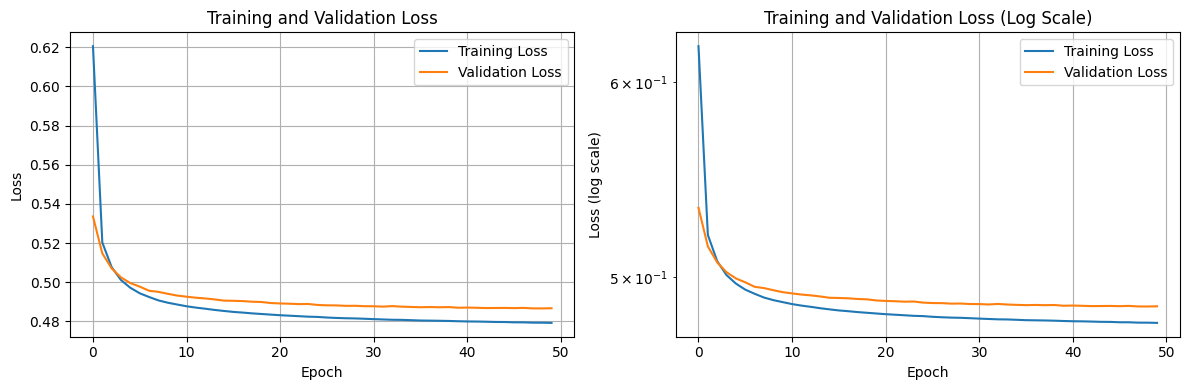

In [6]:
# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogy(train_losses, label='Training Loss')
plt.semilogy(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training and Validation Loss (Log Scale)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Evaluating Compression Quality

IndexError: index 6 is out of bounds for axis 0 with size 6

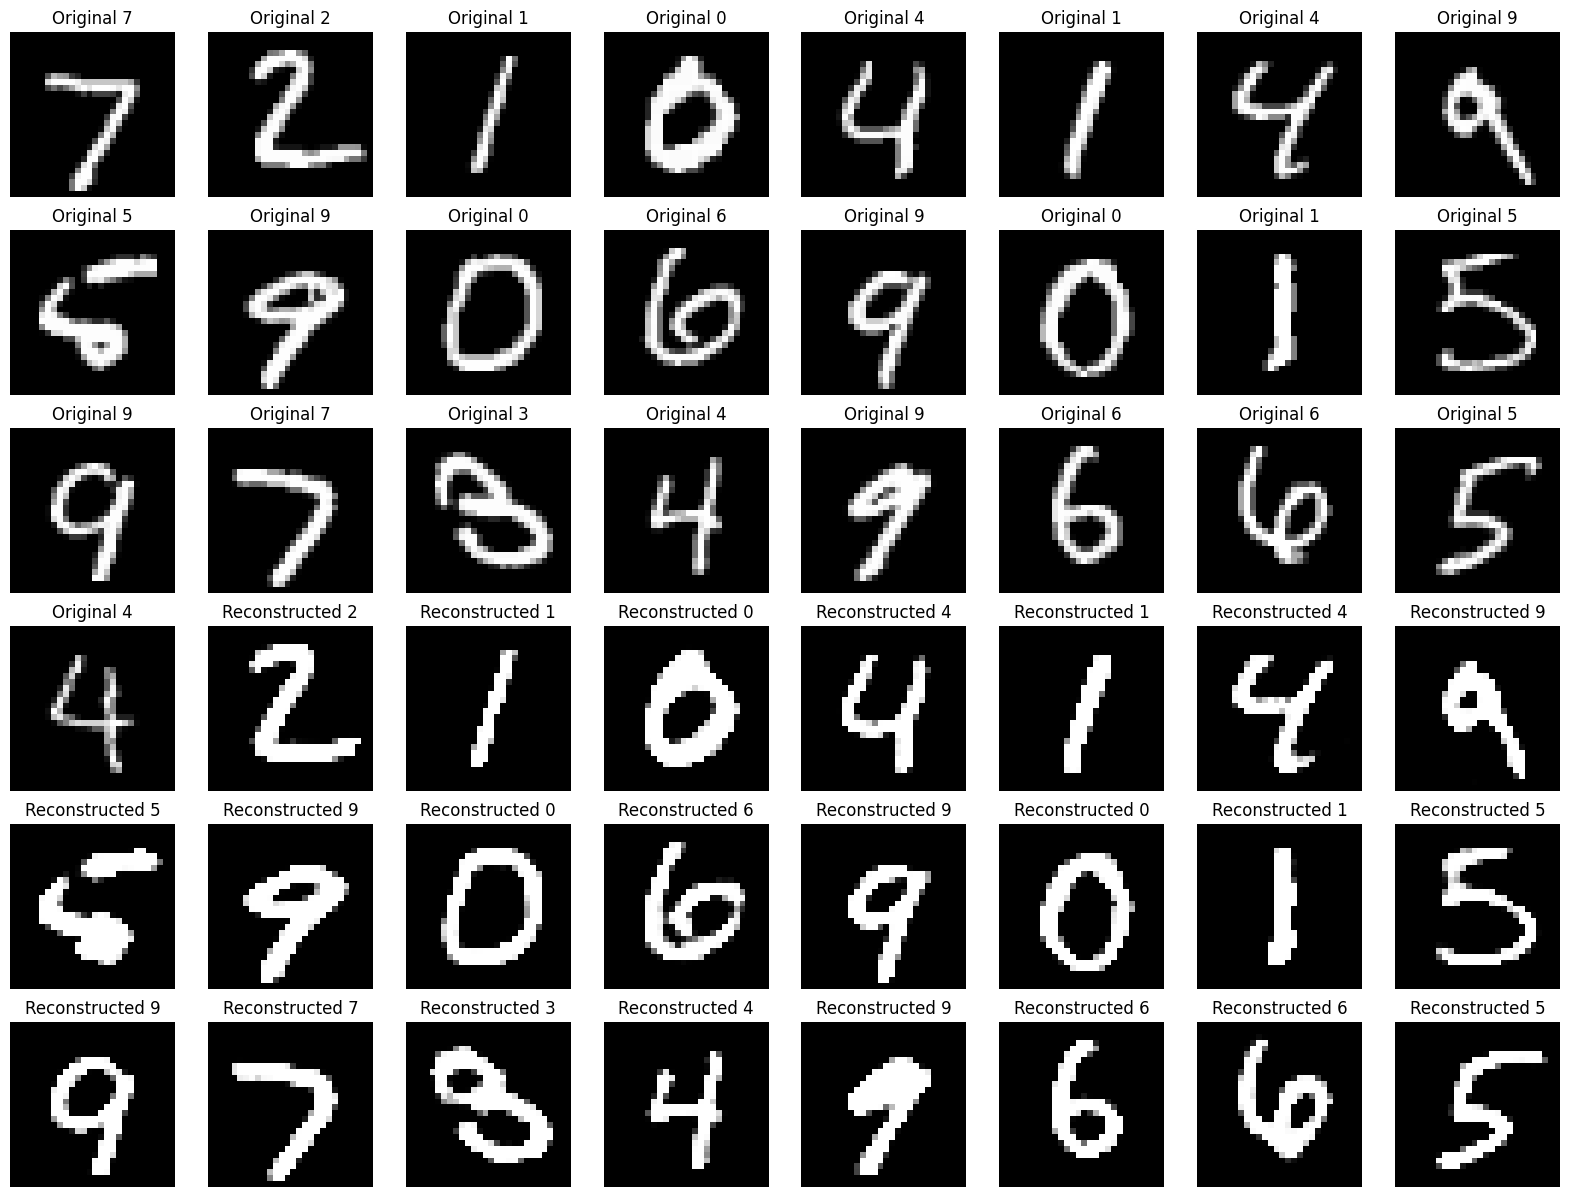

In [10]:
# Test reconstruction quality
autoencoder.eval()
test_images = []
reconstructed_images = []
latent_representations = []
labels = []

with torch.no_grad():
    for i, (data, target) in enumerate(test_loader):
        if i >= 2:  # Take first 2 batches for visualization
            break
        data = data.to(device)
        reconstructed, latent = autoencoder(data)
        
        test_images.append(data.cpu())
        reconstructed_images.append(reconstructed.view(data.size(0), 1, 28, 28).cpu())
        latent_representations.append(latent.cpu())
        labels.append(target)

# Concatenate results
test_images = torch.cat(test_images, dim=0)
reconstructed_images = torch.cat(reconstructed_images, dim=0)
latent_representations = torch.cat(latent_representations, dim=0)
labels = torch.cat(labels, dim=0)

# Visualize original vs reconstructed images
fig, axes = plt.subplots(6, 8, figsize=(20, 15))  # Changed from (4, 8) to (6, 8)
for i in range(32):
    row, col = i // 8, i % 8
    
    # Original image
    axes[row, col].imshow(test_images[i].squeeze(), cmap='gray')
    axes[row, col].set_title(f'Original {labels[i]}')
    axes[row, col].axis('off')
    
    # Reconstructed image
    axes[row+3, col].imshow(reconstructed_images[i].squeeze(), cmap='gray')  # Changed from row+2 to row+3
    axes[row+3, col].set_title(f'Reconstructed {labels[i]}')
    axes[row+3, col].axis('off')

plt.suptitle('Original vs Reconstructed Images', fontsize=16)
plt.tight_layout()
plt.show()

# Calculate reconstruction error
mse_loss = nn.MSELoss()(reconstructed_images.view(-1, 784), test_images.view(-1, 784))
print(f"Average reconstruction error (MSE): {mse_loss:.6f}")
print(f"Compression ratio: {compression_ratio:.1f}%")
print(f"Compression achieved: {784} → {latent_dim} dimensions")

## 6. Latent Space Analysis

Computing t-SNE embedding of latent space...


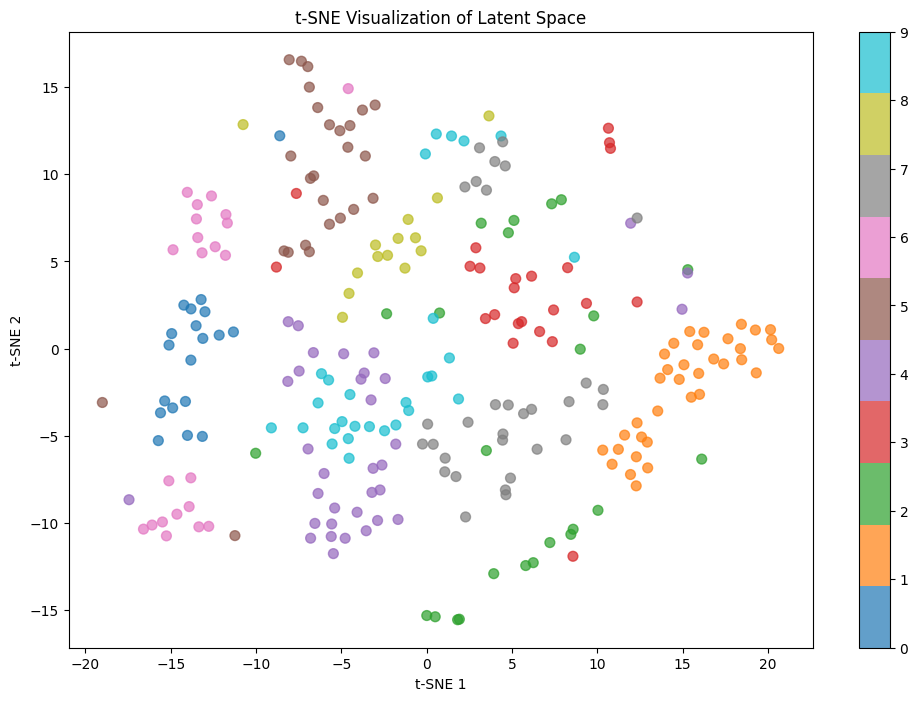


Latent Space Statistics:
Latent space shape: torch.Size([256, 32])
Mean of latent vectors: -0.8953
Std of latent vectors: 4.0460
Min value: -14.0354
Max value: 13.0969


In [11]:
# Visualize latent space using t-SNE
print("Computing t-SNE embedding of latent space...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(latent_representations.numpy())

plt.figure(figsize=(12, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels.numpy(), 
                     cmap='tab10', alpha=0.7, s=50)
plt.colorbar(scatter)
plt.title('t-SNE Visualization of Latent Space')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# Analyze latent space statistics
print("\nLatent Space Statistics:")
print(f"Latent space shape: {latent_representations.shape}")
print(f"Mean of latent vectors: {latent_representations.mean():.4f}")
print(f"Std of latent vectors: {latent_representations.std():.4f}")
print(f"Min value: {latent_representations.min():.4f}")
print(f"Max value: {latent_representations.max():.4f}")

## 7. Demonstrating Lack of Generative Capacity

This is a crucial section that shows why autoencoders are not generative models. We'll demonstrate that:
1. Random sampling from latent space produces poor results
2. Interpolation in latent space is not smooth
3. The latent space is not structured for generation

Test 1: Random sampling from latent space
This should produce poor quality, unrecognizable images...


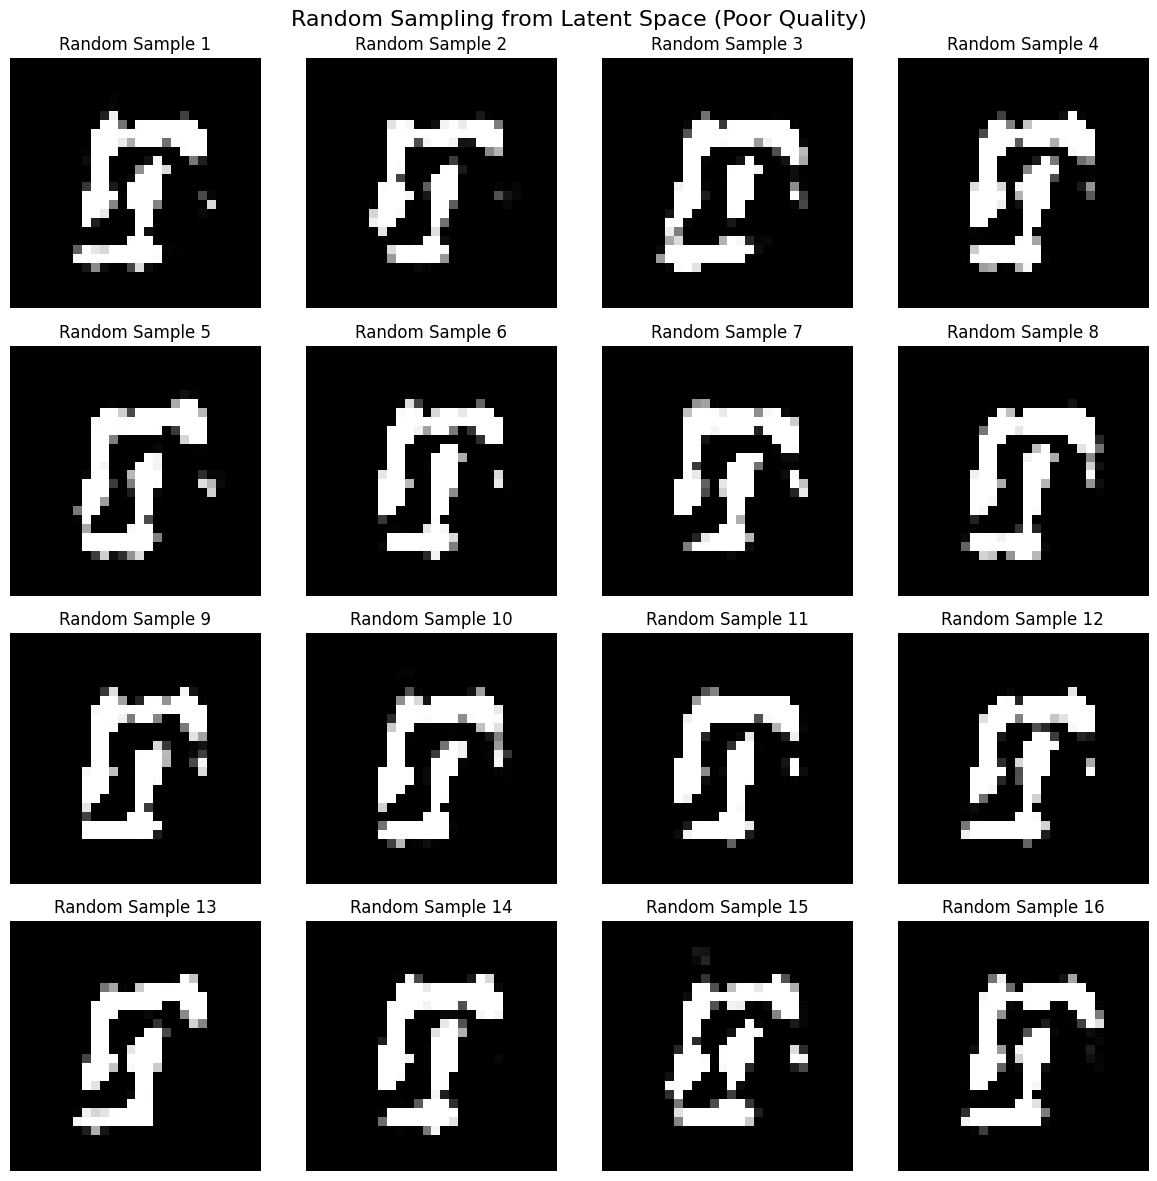


As expected, random sampling produces poor quality images!


In [12]:
# Test 1: Random sampling from latent space
print("Test 1: Random sampling from latent space")
print("This should produce poor quality, unrecognizable images...")

autoencoder.eval()
with torch.no_grad():
    # Sample random latent vectors
    random_latent = torch.randn(16, latent_dim).to(device)
    
    # Decode to images
    generated_images = autoencoder.decode(random_latent)
    generated_images = generated_images.view(16, 1, 28, 28).cpu()

# Visualize randomly generated images
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i in range(16):
    row, col = i // 4, i % 4
    axes[row, col].imshow(generated_images[i].squeeze(), cmap='gray')
    axes[row, col].set_title(f'Random Sample {i+1}')
    axes[row, col].axis('off')

plt.suptitle('Random Sampling from Latent Space (Poor Quality)', fontsize=16)
plt.tight_layout()
plt.show()

print("\nAs expected, random sampling produces poor quality images!")

Test 2: Interpolation between two real images
This should show non-smooth transitions...


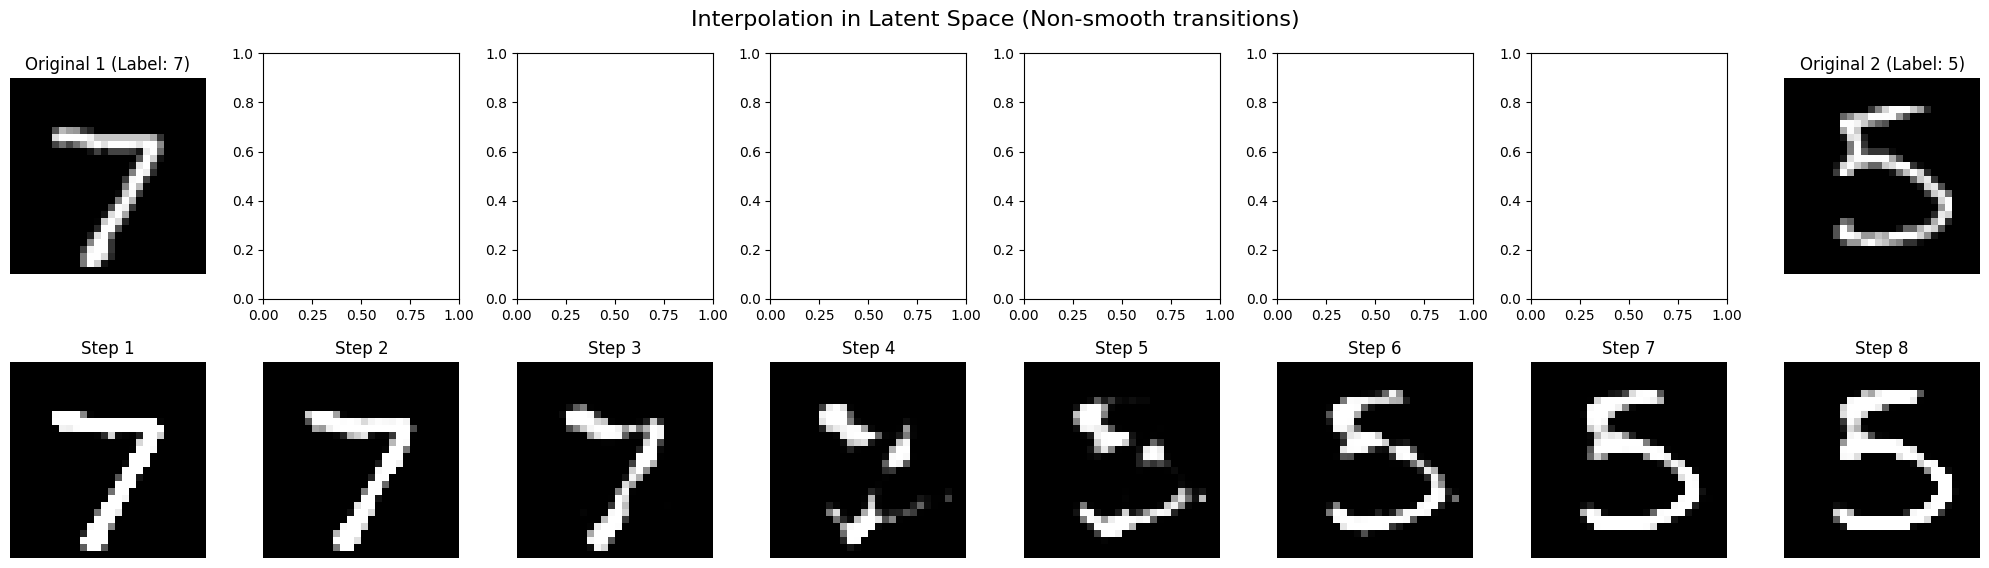


The interpolation shows non-smooth transitions, indicating poor latent space structure!


In [13]:
# Test 2: Interpolation between two real images
print("Test 2: Interpolation between two real images")
print("This should show non-smooth transitions...")

# Get two different images
img1_idx = 0  # First image
img2_idx = 15  # Different image

autoencoder.eval()
with torch.no_grad():
    # Get latent representations of two images
    latent1 = autoencoder.encode(test_images[img1_idx:img1_idx+1].to(device))
    latent2 = autoencoder.encode(test_images[img2_idx:img2_idx+1].to(device))
    
    # Create interpolation steps
    num_steps = 8
    interpolated_images = []
    
    for alpha in np.linspace(0, 1, num_steps):
        interpolated_latent = alpha * latent2 + (1 - alpha) * latent1
        interpolated_image = autoencoder.decode(interpolated_latent)
        interpolated_images.append(interpolated_image.view(1, 28, 28).cpu())

# Visualize interpolation
fig, axes = plt.subplots(2, num_steps, figsize=(20, 6))

# Original images
axes[0, 0].imshow(test_images[img1_idx].squeeze(), cmap='gray')
axes[0, 0].set_title(f'Original 1 (Label: {labels[img1_idx]})')
axes[0, 0].axis('off')

axes[0, -1].imshow(test_images[img2_idx].squeeze(), cmap='gray')
axes[0, -1].set_title(f'Original 2 (Label: {labels[img2_idx]})')
axes[0, -1].axis('off')

# Interpolated images
for i, img in enumerate(interpolated_images):
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(f'Step {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Interpolation in Latent Space (Non-smooth transitions)', fontsize=16)
plt.tight_layout()
plt.show()

print("\nThe interpolation shows non-smooth transitions, indicating poor latent space structure!")

Test 3: Analyzing latent space distribution
This shows the latent space is not structured for generation...


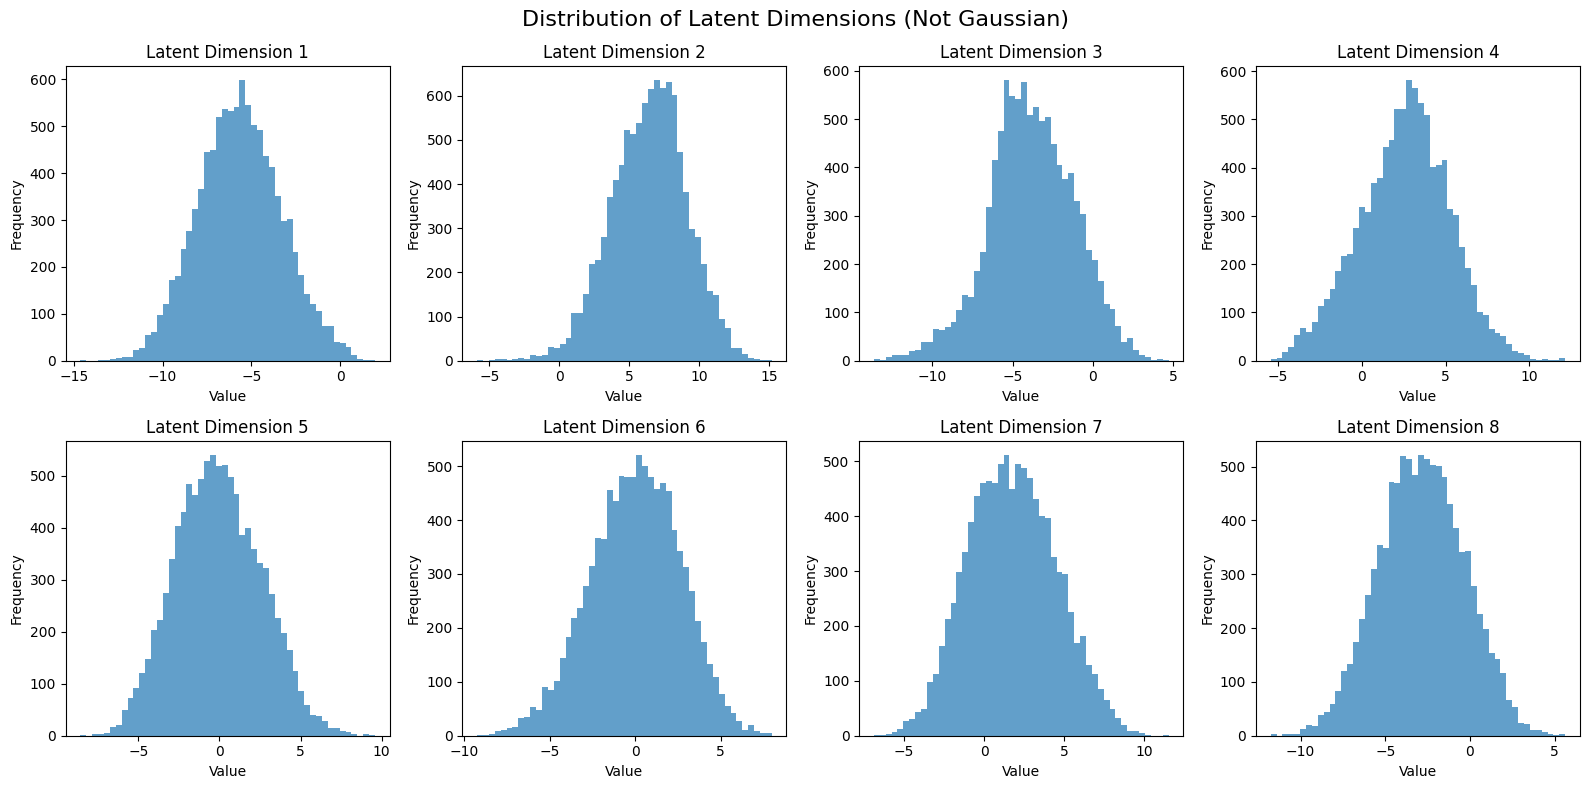


Latent space distribution analysis:
Mean: -0.8447
Std: 4.0940
Skewness: 0.0761
Kurtosis: 3.0918

The distribution is not Gaussian, making random sampling ineffective!


In [14]:
# Test 3: Latent space distribution analysis
print("Test 3: Analyzing latent space distribution")
print("This shows the latent space is not structured for generation...")

# Get latent representations for all test images
all_latents = []
all_labels = []

autoencoder.eval()
with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        latent = autoencoder.encode(data)
        all_latents.append(latent.cpu())
        all_labels.append(target)

all_latents = torch.cat(all_latents, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# Plot distribution of first few latent dimensions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(8):
    row, col = i // 4, i % 4
    axes[row, col].hist(all_latents[:, i].numpy(), bins=50, alpha=0.7)
    axes[row, col].set_title(f'Latent Dimension {i+1}')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')

plt.suptitle('Distribution of Latent Dimensions (Not Gaussian)', fontsize=16)
plt.tight_layout()
plt.show()

# Compare with Gaussian distribution
print("\nLatent space distribution analysis:")
print(f"Mean: {all_latents.mean():.4f}")
print(f"Std: {all_latents.std():.4f}")
print(f"Skewness: {torch.mean(((all_latents - all_latents.mean()) / all_latents.std())**3):.4f}")
print(f"Kurtosis: {torch.mean(((all_latents - all_latents.mean()) / all_latents.std())**4):.4f}")
print("\nThe distribution is not Gaussian, making random sampling ineffective!")

## 8. Comparison with Other Dimensionality Reduction Techniques

Comparing Autoencoder with PCA for dimensionality reduction...

Reconstruction Error Comparison:
Autoencoder MSE: 0.857000
PCA MSE: 0.173801
Autoencoder is worse than PCA


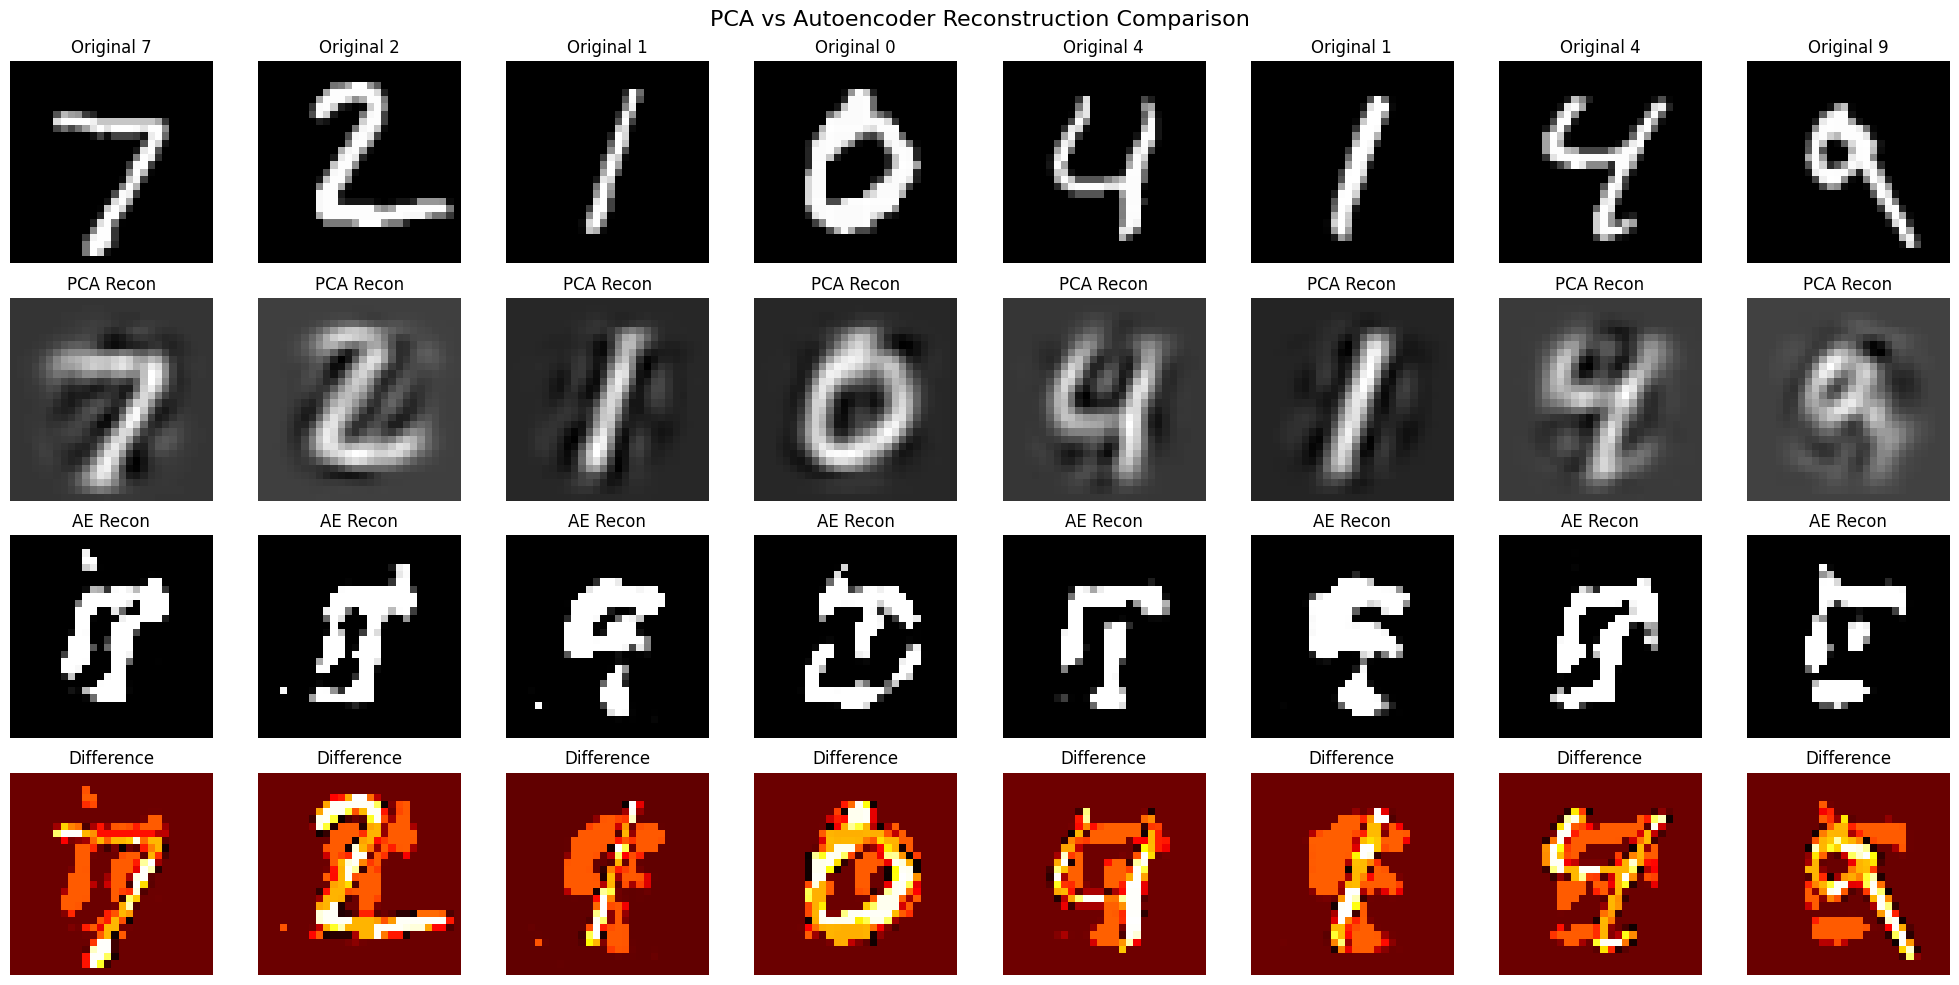

In [15]:
# Compare with PCA
print("Comparing Autoencoder with PCA for dimensionality reduction...")

# Prepare data for PCA
pca_data = []
pca_labels = []

for data, target in test_loader:
    pca_data.append(data.view(data.size(0), -1).cpu())
    pca_labels.append(target)

pca_data = torch.cat(pca_data, dim=0).numpy()
pca_labels = torch.cat(pca_labels, dim=0).numpy()

# Apply PCA
pca = PCA(n_components=latent_dim)
pca_reduced = pca.fit_transform(pca_data)
pca_reconstructed = pca.inverse_transform(pca_reduced)

# Calculate reconstruction errors
ae_reconstruction = autoencoder.decode(torch.tensor(pca_reduced[:100]).float().to(device))
ae_reconstruction = ae_reconstruction.view(100, 1, 28, 28).cpu().detach().numpy()

ae_mse = np.mean((pca_data[:100] - ae_reconstruction.reshape(100, -1))**2)
pca_mse = np.mean((pca_data[:100] - pca_reconstructed[:100])**2)

print(f"\nReconstruction Error Comparison:")
print(f"Autoencoder MSE: {ae_mse:.6f}")
print(f"PCA MSE: {pca_mse:.6f}")
print(f"Autoencoder is {'better' if ae_mse < pca_mse else 'worse'} than PCA")

# Visualize PCA vs Autoencoder reconstructions
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for i in range(8):
    # Original
    axes[0, i].imshow(pca_data[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'Original {pca_labels[i]}')
    axes[0, i].axis('off')
    
    # PCA reconstruction
    axes[1, i].imshow(pca_reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f'PCA Recon')
    axes[1, i].axis('off')
    
    # Autoencoder reconstruction
    axes[2, i].imshow(ae_reconstruction[i].squeeze(), cmap='gray')
    axes[2, i].set_title(f'AE Recon')
    axes[2, i].axis('off')
    
    # Difference
    diff = np.abs(pca_data[i].reshape(28, 28) - ae_reconstruction[i].squeeze())
    axes[3, i].imshow(diff, cmap='hot')
    axes[3, i].set_title(f'Difference')
    axes[3, i].axis('off')

plt.suptitle('PCA vs Autoencoder Reconstruction Comparison', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Summary and Key Insights

### What Autoencoders Do Well:
1. **Dimensionality Reduction**: Successfully compress 784-dimensional data to 32 dimensions (96% compression)
2. **Reconstruction**: Can reconstruct original images with reasonable quality
3. **Feature Learning**: Learn meaningful representations in the latent space
4. **Non-linear Mapping**: Can capture non-linear relationships in data

### What Autoencoders Cannot Do (Generative Limitations):
1. **Random Generation**: Random sampling from latent space produces poor quality images
2. **Smooth Interpolation**: Interpolation between points in latent space is not smooth
3. **Structured Latent Space**: The latent space is not structured for generation
4. **Controlled Generation**: Cannot generate specific types of images on demand

### Why Autoencoders Lack Generative Capacity:
1. **No Regularization**: The latent space is not constrained to follow a specific distribution
2. **Training Objective**: Only optimizes for reconstruction, not generation
3. **No Prior**: No prior distribution is imposed on the latent space
4. **Discontinuous Mapping**: The encoder-decoder mapping can be discontinuous

### Solutions for Generative Models:
1. **Variational Autoencoders (VAEs)**: Add KL divergence to regularize latent space
2. **Generative Adversarial Networks (GANs)**: Use adversarial training
3. **Normalizing Flows**: Learn invertible transformations
4. **Diffusion Models**: Learn denoising process

This demonstrates why autoencoders are excellent for compression and feature learning but not for generation!

In [ ]:
# Save the trained model
torch.save(autoencoder.state_dict(), 'data/autoencoder_mnist.pth')
print("Model saved to 'data/autoencoder_mnist.pth'")

# Final summary
print("\n" + "="*60)
print("AUTOENCODER ANALYSIS SUMMARY")
print("="*60)
print(f"✓ Compression achieved: {784} → {latent_dim} dimensions ({compression_ratio:.1f}% reduction)")
print(f"✓ Reconstruction quality: MSE = {mse_loss:.6f}")
print(f"✗ Generative capacity: Random sampling produces poor results")
print(f"✗ Latent space structure: Not suitable for generation")
print("="*60)
print("\nKey Takeaway: Autoencoders are great for compression but lack generative capacity!")
print("For generative models, consider VAEs, GANs, or diffusion models.")